In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder

from tqdm.notebook import tqdm
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from collections import Counter

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [2]:
import timm

num_classes = 3
model = timm.create_model('resnet50', pretrained = True, num_classes = num_classes).to(device)

In [5]:
#!pip install torchsummaryX

In [397]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
         Identity-10           [-1, 64, 56, 56]               0
             ReLU-11           [-1, 64, 56, 56]               0
         Identity-12           [-1, 64, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [3]:
#true 시 모든 레이어 학습
for i, (name, layer) in enumerate(model.named_parameters()):
    if i == len(list(model.named_parameters())) - 1:
        break
    layer.requires_grad = True
# resnet에만 해당되니 위에 코드만 주석을 풀어서 사용!!! False
# layer.fc.requires_grad = True 

In [4]:
transformer = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
])
transformer

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [5]:
data_dir = './new_data'
dataset = ImageFolder(data_dir, transformer)

train_size = int(0.6 * len(dataset))
valid_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - valid_size

seed = 42
torch.manual_seed(seed)
train_dataset, valid_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, valid_size, test_size])

train_loader = DataLoader(train_dataset, batch_size = 1, shuffle = False)
valid_loader = DataLoader(valid_dataset, batch_size = 1, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 1, shuffle = False)

In [5]:
for x, y in train_loader:
    break

x = np.transpose(x, (0,2,3,1))[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


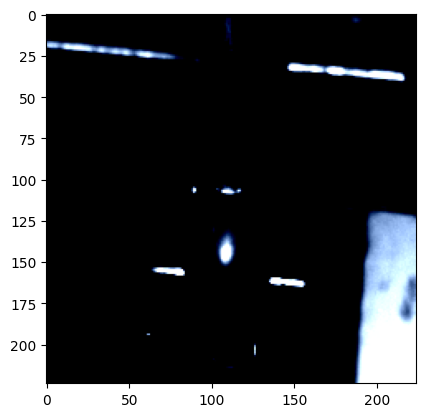

In [6]:
import matplotlib.pyplot as plt

plt.imshow(x)

In [8]:
dataset.classes

['normal', 'over', 'under']

In [9]:
train_class_num = {f'{i}':0 for i in range(3)}
valid_class_num = {f'{i}':0 for i in range(3)}
test_class_num = {f'{i}':0 for i in range(3)}

for _, y in tqdm(train_loader):
    train_class_num[f'{y.item()}'] += 1

for _, y in tqdm(valid_loader):
    valid_class_num[f'{y.item()}'] += 1

for _, y in tqdm(test_loader):
    test_class_num[f'{y.item()}'] += 1

  0%|          | 0/18607 [00:00<?, ?it/s]

  0%|          | 0/6202 [00:00<?, ?it/s]

  0%|          | 0/6204 [00:00<?, ?it/s]

In [10]:
for idx, class_num in train_class_num.items():
    print(dataset.classes[int(idx)], class_num)

normal 17887
over 350
under 370


In [11]:
for idx, class_num in valid_class_num.items():
    print(dataset.classes[int(idx)], class_num)

normal 5974
over 96
under 132


In [12]:
for idx, class_num in test_class_num.items():
    print(dataset.classes[int(idx)], class_num)

normal 5953
over 121
under 130


In [13]:
train_classes = [label for _, label in tqdm(train_dataset)]
class_count = Counter(train_classes)
class_weights = torch.Tensor([len(train_classes)/c for c in pd.Series(class_count).sort_index().values])
sampler_weights = [0] * len(train_dataset)

for idx, (image, label) in enumerate(train_dataset):
    class_weight = class_weights[label]
    sampler_weights[idx] = class_weight

  0%|          | 0/18607 [00:00<?, ?it/s]

In [14]:
sampler = WeightedRandomSampler(weights = sampler_weights,
                               num_samples = len(train_dataset), replacement = True)

# training code

In [399]:
def train(model, loader, criterion, optimizer):
    '''
    학습을 위한 함수
    '''
    model.train()
    train_loss = 0.
    train_acc = 0.
    
    with tqdm(loader, unit = 'batch') as tepoch:
      for X, y in tepoch:
          tepoch.set_description('Training')
          #X = X.view(32,1,28,28)
          X = X.to(device)
          y = y.to(device)
      
          y_hat = model(X)
          loss = criterion(y_hat, y)
      
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()
          # loss
          train_loss += loss.item()
      
          # acc
          pred = y_hat.max(1, keepdim = True)[1]
          iter_acc = pred.eq(y.data.view_as(pred)).sum().item()
          train_acc += iter_acc
      
          tepoch.set_postfix(loss=loss.item(), acc = iter_acc)
    
    train_loss  = train_loss / len(loader)
    train_acc = train_acc / len(loader.dataset)
    
    return train_loss, train_acc

def val(model, loader, criterion):
    '''
    검증을 위한 함수
    '''
    model.eval()
    val_loss = 0.
    val_acc = 0.
    
    with tqdm(loader, unit = 'batch') as tepoch:
      with torch.no_grad():
        for X, y in tepoch:
            tepoch.set_description('Evaluation')
            #X = X.view(32,1,28,28)
            X = X.to(device)
            y = y.to(device)
    
            y_hat = model(X)
            loss = criterion(y_hat, y)
            val_loss += loss.item()
    
            # acc
            pred = y_hat.max(1, keepdim = True)[1]
            iter_acc = pred.eq(y.data.view_as(pred)).sum().item()
            val_acc += iter_acc
    
            tepoch.set_postfix(loss=loss.item(), acc = iter_acc)
    
    val_loss  = val_loss / len(loader)
    val_acc = val_acc / len(loader.dataset)
    
    return val_loss, val_acc

In [400]:
LEARNING_RATE = 0.001
MODEL_NAME = 'resnet152_pretrained_true_shuffle_true_require_true'
OPTIMIZER = 'AdamW'

epochs = 30
if OPTIMIZER == 'AdamW':
    optimizer = torch.optim.AdamW(model.parameters(), lr = 0.001, weight_decay=1e-5)
elif OPTIMIZER == 'AdamW':
    optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, weight_decay=1e-5)
elif OPTIMIZER == 'SGD':
    optimizer = torch.optim.SGD(model.parameters(), lr = 0.01, momentum = 0.9)

criterion = nn.CrossEntropyLoss().to(device)

In [12]:
train_loss_list = []
train_acc_list = []
val_loss_list = []
val_acc_list = []
#위 코드는 sampler true, 아래 코드는 sampler 없는 것 모델 구분해서 할 것
#train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = False, sampler = sampler)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = False)
valid_loader = DataLoader(valid_dataset, batch_size = 16, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)

In [ ]:
high_acc = 0.0

for epoch in range(epochs):
    print(f'########### EPOCH : {epoch + 1} / {epochs} ###########')
    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    val_loss, val_acc = val(model, valid_loader, criterion)
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)
    
    print(f"Train_loss={train_loss:.3f} Valid_loss={val_loss:.3f} Train_accuracy={train_acc*100:.2f}% Valid_accuracy={val_acc*100:.2f}%")
    
    if val_acc > high_acc:
        print(f"* Valid_Accuracy가 향상되었습니다. {high_acc:.3f} ==> {val_acc:.3f}")
        high_acc = val_acc
        torch.save(model.state_dict(), f'./models/pretrained_all_{MODEL_NAME}_optim_{OPTIMIZER}_lr_{LEARNING_RATE}.pt')
    else:
        print('* Valid_Accuracy가 향상되지 않았습니다.')

########### EPOCH : 1 / 30 ###########


  0%|          | 0/582 [00:00<?, ?batch/s]

  0%|          | 0/388 [00:00<?, ?batch/s]

Train_loss=0.193 Valid_loss=0.113 Train_accuracy=93.09% Valid_accuracy=95.76%
* Valid_Accuracy가 향상되었습니다. 0.000 ==> 0.958
########### EPOCH : 2 / 30 ###########


  0%|          | 0/582 [00:00<?, ?batch/s]

  0%|          | 0/388 [00:00<?, ?batch/s]

Train_loss=0.092 Valid_loss=0.217 Train_accuracy=97.10% Valid_accuracy=92.37%
* Valid_Accuracy가 향상되지 않았습니다.
########### EPOCH : 3 / 30 ###########


  0%|          | 0/582 [00:00<?, ?batch/s]

# confusion matrix

In [22]:
MODEL_NAME = 'resnet_pretrained_True_shuffle_false'
OPTIMIZER = 'AdamW'
LEARNING_RATE = 0.001

In [23]:
import torch
model.load_state_dict(torch.load(f'./models/pretrained_all_{MODEL_NAME}_optim_{OPTIMIZER}_lr_{LEARNING_RATE}.pt'))

<All keys matched successfully>

In [21]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = False)

In [22]:
labels = []
preds = []

model.eval()
with torch.no_grad():
  for img, label in tqdm(train_loader):
    labels.append(label.numpy())

    img = img.to(device)
    pred = model(img).max(1, keepdim = True)[1].detach().to('cpu').numpy().reshape(-1)
    preds.append(pred)

if len(preds[0]) != len(preds[-1]):
    first_np = np.array(preds[:-1]).reshape(-1)
    ow_np = np.array(preds[-1]).reshape(-1)

    first_np_2 = np.array(labels[:-1]).reshape(-1)
    ow_np_2 = np.array(labels[-1]).reshape(-1)
    
    predictions = np.concatenate([first_np, ow_np])
    classes = np.concatenate([first_np_2, ow_np_2])
else:
    predictions = np.array(preds).reshape(-1)
    classes = np.array(labels).reshape(-1)

cm = confusion_matrix(classes, predictions)
cm_df = pd.DataFrame(cm)
cm_df.columns = dataset.classes
cm_df.index = dataset.classes

plt.figure(figsize = (10,7))
sns.heatmap(cm_df, annot = True, fmt = 'd', cmap='YlGnBu')
plt.yticks(rotation = 360)
plt.xlabel('model pred')
plt.ylabel('label', rotation = 360, labelpad = 20)
plt.title('train confusion matrix')
plt.show()

  0%|          | 0/582 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
labels = []
preds = []

model.eval()
with torch.no_grad():
  for img, label in tqdm(valid_loader):
    labels.append(label.numpy())

    img = img.to(device)
    pred = model(img).max(1, keepdim = True)[1].detach().to('cpu').numpy().reshape(-1)
    preds.append(pred)

if len(preds[0]) != len(preds[-1]):
    first_np = np.array(preds[:-1]).reshape(-1)
    ow_np = np.array(preds[-1]).reshape(-1)

    first_np_2 = np.array(labels[:-1]).reshape(-1)
    ow_np_2 = np.array(labels[-1]).reshape(-1)
    
    predictions = np.concatenate([first_np, ow_np])
    classes = np.concatenate([first_np_2, ow_np_2])
else:
    predictions = np.array(preds).reshape(-1)
    classes = np.array(labels).reshape(-1)

cm = confusion_matrix(classes, predictions)
cm_df = pd.DataFrame(cm)
cm_df.columns = dataset.classes
cm_df.index = dataset.classes

plt.figure(figsize = (10,7))
sns.heatmap(cm_df, annot = True, fmt = 'd', cmap='YlGnBu')
plt.yticks(rotation = 360)
plt.xlabel('model pred')
plt.ylabel('label', rotation = 360, labelpad = 20)
plt.title('valid confusion matrix')
plt.show()

  0%|          | 0/388 [00:00<?, ?it/s]

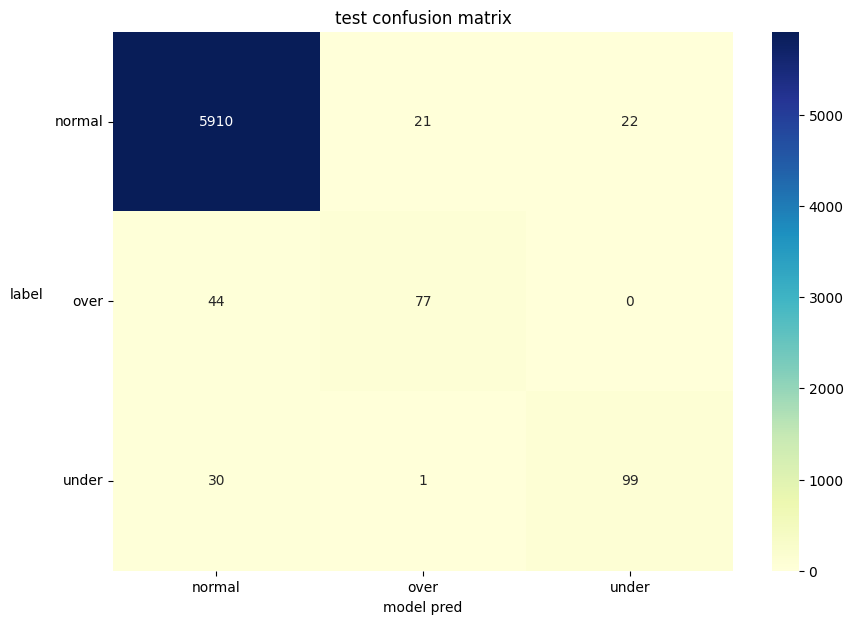

In [23]:
labels = []
preds = []

model.eval()
with torch.no_grad():
  for img, label in tqdm(test_loader):
    labels.append(label.numpy())

    img = img.to(device)
    pred = model(img).max(1, keepdim = True)[1].detach().to('cpu').numpy().reshape(-1)
    preds.append(pred)

if len(preds[0]) != len(preds[-1]):
    first_np = np.array(preds[:-1]).reshape(-1)
    ow_np = np.array(preds[-1]).reshape(-1)

    first_np_2 = np.array(labels[:-1]).reshape(-1)
    ow_np_2 = np.array(labels[-1]).reshape(-1)
    
    predictions = np.concatenate([first_np, ow_np])
    classes = np.concatenate([first_np_2, ow_np_2])
else:
    predictions = np.array(preds).reshape(-1)
    classes = np.array(labels).reshape(-1)

cm = confusion_matrix(classes, predictions)
cm_df = pd.DataFrame(cm)
cm_df.columns = dataset.classes
cm_df.index = dataset.classes

plt.figure(figsize = (10,7))
sns.heatmap(cm_df, annot = True, fmt = 'd', cmap='YlGnBu')
plt.yticks(rotation = 360)
plt.xlabel('model pred')
plt.ylabel('label', rotation = 360, labelpad = 20)
plt.title('test confusion matrix')
plt.show()

In [28]:
test_image = np.transpose(img.detach().to('cpu').numpy(), (0,2,3,1))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


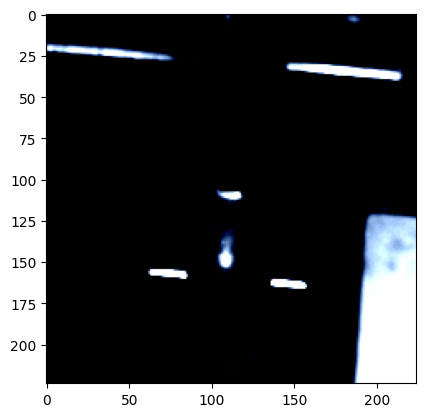

In [35]:
plt.imshow(test_image[11])

In [ ]:
from sklearn.metrics import f1_score
f1_score(classes, predictions, average = 'weighted')

In [20]:
dataset.samples

dataloader = DataLoader(dataset, batch_size = 1, shuffle = False)

In [21]:
dataloader

In [24]:
from tqdm.notebook import tqdm
label_lst = []
pred_lst = []
path_lst = []
with torch.no_grad():
    model.eval()
    for image, class_id in tqdm(dataloader):
        image = image.to(device)
        label = label
        pred = model(image).max(1, keepdim = True)[1].detach().to('cpu').numpy().reshape(-1)
        label_lst.append(label)
        pred_lst.append(pred)

  0%|          | 0/31013 [00:00<?, ?it/s]

NameError: name 'label' is not defined